# Lab Assignment 2 - Part C: Naive Bayes for Spam Detection
Please refer to the `README.pdf` for full laboratory instructions.


## Problem Statement
In this part, you will implement a **Naive Bayes classifier** for spam email detection using the Spambase dataset.

### Dataset Description
The Spambase dataset contains 4601 email samples with 57 features:
- **Features 1-48**: Word frequencies (percentage of words matching specific words)
- **Features 49-54**: Character frequencies (`;`, `(`, `[`, `!`, `$`, `#`)
- **Features 55-57**: Capital letter statistics
- **Label**: 1 = spam, 0 = not spam

### Your Tasks
1. **Implement Gaussian Naive Bayes** from scratch
2. **Train and evaluate** your classifier (accuracy, precision, recall, F1-score)
3. **Feature analysis**: Identify top discriminative features
4. **Discussion**: Why does Naive Bayes work for spam detection?


## Setup


In [1]:
%pip install ucimlrepo


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Library declarations
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo


## Load the Spambase Dataset


In [3]:
# Fetch Spambase dataset from UCI ML Repository
spambase = fetch_ucirepo(id=94)

# Get features and labels
X = spambase.data.features.values
y = spambase.data.targets.values.ravel()

print(f"Dataset shape: {X.shape}")
print(f"Number of spam emails: {np.sum(y == 1)}")
print(f"Number of non-spam emails: {np.sum(y == 0)}")
print(f"\nFeature names: {list(spambase.data.features.columns[:10])}...")  # First 10 features


Dataset shape: (4601, 57)
Number of spam emails: 1813
Number of non-spam emails: 2788

Feature names: ['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail']...


In [4]:
# Split data into training (80%) and testing (20%) sets
def train_test_split(X, y, test_size=0.2, random_state=42):
    """
    Split data into training and testing sets.
    """
    np.random.seed(random_state)
    n_samples = len(y)
    indices = np.random.permutation(n_samples)
    test_size = int(n_samples * test_size)
    
    test_indices = indices[:test_size]
    train_indices = indices[test_size:]
    
    return X[train_indices], X[test_indices], y[train_indices], y[test_indices]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")


Training set: 3681 samples
Testing set: 920 samples


## Task 1: Implement Gaussian Naive Bayes
Implement a Gaussian Naive Bayes classifier from scratch.

**Key formulas:**
- Class prior: $P(C) = \frac{N_C}{N}$
- Gaussian likelihood: $P(x_i|C) = \frac{1}{\sqrt{2\pi\sigma_{i,C}^2}} \exp\left(-\frac{(x_i - \mu_{i,C})^2}{2\sigma_{i,C}^2}\right)$
- Use **log-probabilities** to avoid numerical underflow!


In [ ]:
class GaussianNaiveBayes:
    """
    Gaussian Naive Bayes classifier implementation.
    """
    
    def __init__(self):
        self.classes = None
        self.priors = None      # P(C) for each class
        self.means = None       # Mean of each feature per class
        self.variances = None   # Variance of each feature per class
    
    def fit(self, X, y):
        """
        Train the Naive Bayes classifier.
        
        Parameters:
        -----------
        X : numpy array of shape (n_samples, n_features)
        y : numpy array of shape (n_samples,)
        """
        # TODO: Implement training
        # 1. Get unique classes
        # 2. Calculate class priors P(C)
        # 3. Calculate mean and variance for each feature per class
        # Hint: Add a small epsilon to variance to avoid division by zero
        self.classes = np.unique(y)
        self.priors = np.array([np.mean(y == c) for c in self.classes])
        self.means = np.array([X[y == c].mean(axis=0) for c in self.classes])
        self.variances = np.array([X[y == c].var(axis=0) + 1e-9 for c in self.classes])

        # pass
    
    def _gaussian_log_likelihood(self, x, mean, var):
        """
        Calculate log of Gaussian probability density.
        
        Returns:
        --------
        log_likelihood : float
        """
        # TODO: Implement log of Gaussian PDF
        return -0.5 * np.sum(np.log(2 * np.pi * var) + (x - mean) ** 2 / var)
    
    def predict(self, X):
        """
        Predict class labels for samples in X.
        
        Parameters:
        -----------
        X : numpy array of shape (n_samples, n_features)
        
        Returns:
        --------
        predictions : numpy array of shape (n_samples,)
        """
        # TODO: Implement prediction
        # For each sample:
        #   1. Calculate log P(C) + sum of log P(x_i|C) for each class
        #   2. Return the class with highest log probability
        log_probs = np.array([
            np.log(prior) + np.array([self._gaussian_log_likelihood(x, mean, var)
                                       for x in X])
            for prior, mean, var in zip(self.priors, self.means, self.variances)
        ])
        return self.classes[np.argmax(log_probs, axis=0)]
    
    def predict_proba(self, X):
        """
        Return probability estimates for samples.
        
        Returns:
        --------
        probabilities : numpy array of shape (n_samples, n_classes)
        """
        # TODO: (Optional) Implement probability estimation
        log_probs = np.array([
            np.log(prior) + np.array([self._gaussian_log_likelihood(x, mean, var)
                                       for x in X])
            for prior, mean, var in zip(self.priors, self.means, self.variances) ]).T
        log_probs -= log_probs.max(axis=1, keepdims=True)
        probs = np.exp(log_probs)
        return probs / probs.sum(axis=1, keepdims=True)


## Task 2: Train and Evaluate
Train your classifier and compute evaluation metrics.


In [6]:
def compute_metrics(y_true, y_pred):
    """
    Compute classification metrics.
    
    Returns:
    --------
    accuracy, precision, recall, f1_score : floats
    """
    # TODO: Implement metrics computation
    # Accuracy = (TP + TN) / (TP + TN + FP + FN)
    # Precision = TP / (TP + FP)
    # Recall = TP / (TP + FN)
    # F1 = 2 * (Precision * Recall) / (Precision + Recall)
    TP = np.sum((y_pred == 1) & (y_true == 1))
    TN = np.sum((y_pred == 0) & (y_true == 0))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))
    accuracy  = (TP + TN) / len(y_true)
    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    f1 = 2 * precision * recall / (precision + recall)
    return accuracy, precision, recall, f1



def confusion_matrix(y_true, y_pred):
    """
    Create confusion matrix.
    
    Returns:
    --------
    matrix : numpy array of shape (2, 2)
        [[TN, FP], [FN, TP]]
    """
    # TODO: Implement confusion matrix
    TP = np.sum((y_pred == 1) & (y_true == 1))
    TN = np.sum((y_pred == 0) & (y_true == 0))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))
    return np.array([[TN, FP], [FN, TP]])
    


## Task 3: Feature Analysis
Identify the most discriminative features for spam detection.


In [7]:
# TODO: Train your classifier
nb_classifier = GaussianNaiveBayes()
nb_classifier.fit(X_train, y_train)

# TODO: Make predictions
y_pred = nb_classifier.predict(X_test)

# TODO: Compute and print metrics
accuracy, precision, recall, f1 = compute_metrics(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# TODO: Create and display confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(cm)


Accuracy: 0.8217
Precision: 0.7233
Recall: 0.9385
F1-Score: 0.8170

Confusion Matrix:
[[390 140]
 [ 24 366]]


In [10]:
feature_names = list(spambase.data.features.columns)
# TODO: Identify top 5 most discriminative features
# Hint: You can measure discriminative power by:
# - Difference in means between classes (normalized by pooled std)
# - Or by feature importance based on model weights
scores = []
for i in range(X.shape[1]):
    spam     = X[y == 1, i]
    not_spam = X[y == 0, i]
    pooled_std = np.sqrt((spam.var() + not_spam.var()) / 2) + 1e-9
    scores.append(abs(spam.mean() - not_spam.mean()) / pooled_std) #difference in mean

top5 = np.argsort(scores)[::-1][:5]
print("Top 5 most discriminative features:")
for idx in top5:
    print(f"  {feature_names[idx]}: score = {scores[idx]:.4f}")

# feature_names = list(spambase.data.features.columns)

# TODO: Calculate discriminative score for each feature
# discriminative_scores = []
# for i in range(X.shape[1]):
#     # Calculate how different the feature distributions are for spam vs non-spam
#     pass

# TODO: Get top 5 features
# top_5_indices = ...
# print("Top 5 most discriminative features:")
# for idx in top_5_indices:
#     print(f"  {feature_names[idx]}: score = ...")


Top 5 most discriminative features:
  word_freq_your: score = 0.8329
  word_freq_000: score = 0.6484
  word_freq_remove: score = 0.6458
  char_freq_$: score = 0.6274
  word_freq_hp: score = 0.5978


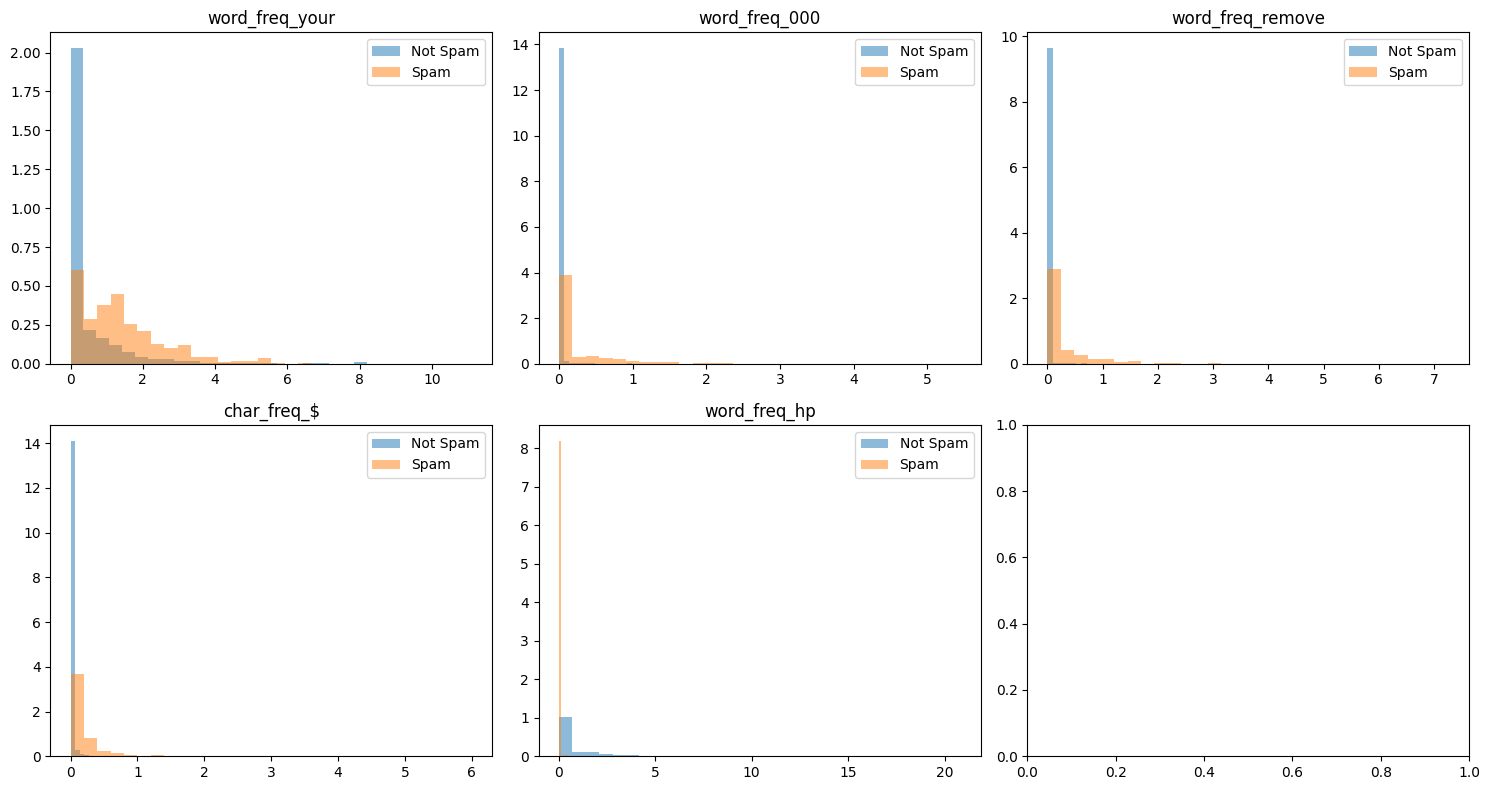

In [11]:
# TODO: Visualize distributions of top features for spam vs non-spam
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, idx in enumerate(top_5_indices[:5]):
    ax = axes[i // 3, i % 3]
    ax.hist(X[y == 0, idx], bins=30, alpha=0.5, label='Not Spam', density=True)
    ax.hist(X[y == 1, idx], bins=30, alpha=0.5, label='Spam', density=True)
    ax.set_title(f'{feature_names[idx]}')
    ax.legend()
plt.tight_layout()
plt.show()


## Summary and Discussion

### Results Table
| Metric | Value |
|--------|-------|
| Accuracy | 0.8217 |
| Precision | 0.7233 |
| Recall | 0.9385 |
| F1-Score | 0.8170 |

### Top 5 Discriminative Features
1. word_freq_your: 0.8329
2. word_freq_000: 0.6484
3. word_freq_remove: 0.6458
4. char_freq_$: 0.6274
5. word_freq_hp: 0.5978

### Discussion
*Answer these questions:*
1. Why is Naive Bayes effective for spam detection despite the independence assumption?
Even though words aren't truly independent in emails, the independence assumption works well enough in practice because the model just needs to rank classes correctly, not estimate probabilities accurately. Spam emails tend to have strong word signals like "remove", "$", "000", that dominate regardless of correlations.
2. What are the limitations of your implementation?
The Gaussian assumption is a poor fit for word frequency features since they are heavily right-skewed, and in turn not bell-shaped. This hurts precision with 140 false positives, since the model is overconfident on some non-spam emails.
3. How could you improve the classifier?
Could use a Bernoulli or multinomial Naive Bayes which are better suited for frequency/count data
Log-transforming features before fitting would also make them more Gaussian
4. What did you learn from this exercise?
The independence assumption is rarely true but Naive Bayes is surprisingly robust to it. High recall of 0.94, means it catches almost all spam, which is usually the priority for spam filters.
